# Задание 6

## Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats
from statsmodels.stats.diagnostic import lilliefors

warnings.filterwarnings("ignore")

## Сначала взглянем на данные

In [2]:
initial_df = pd.read_csv("Ames_dataset/AmesHousing.txt", delimiter="\t")
initial_df.head(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Колонки, которые можно взять для разбивки на группы.

In [3]:
initial_df.describe(include=[np.number]).columns

Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='object')

В качестве двух переменных возьмем Lot Area (площадь выставляемого объекта в метрах квадратных) и Year Built (год постройки).

In [4]:
lot_area_median = initial_df["Lot Area"].median()

print(f"Медиана Lot Area равна {lot_area_median}")

group1_by_lot_area = initial_df[initial_df["Lot Area"] <= lot_area_median]
group2_by_lot_area = initial_df[initial_df["Lot Area"] > lot_area_median]

Медиана Lot Area равна 9436.5


In [5]:
year_built_median = initial_df["Year Built"].median()

print(f"Медиана Year Built равна {year_built_median}")

group1_by_year_built = initial_df[initial_df["Year Built"] <= year_built_median]
group2_by_year_built = initial_df[initial_df["Year Built"] > year_built_median]

Медиана Year Built равна 1973.0


## Проверим нормальность распределения SalePrice во всех группах.

In [6]:
groups_dct = {
    "Группа с Lot Area меньше медианы по всему dataset'у": group1_by_lot_area,
    "Группа с Lot Area больше медианы по всему dataset'у": group2_by_lot_area,
    "Группа с Year Built меньше медианы по всему dataset'у": group1_by_year_built,
    "Группа с Year Built больше медианы по всему dataset'у": group2_by_year_built,
    
}

for name_group, group_df in groups_dct.items():
    # Считаем p-value по тесту Шапиро-Уилка
    current_shapiro_p_value = stats.shapiro(group_df["SalePrice"])[1]

    print(f"[Тест ШАПИРО-УИЛКА]: {name_group}, p_value={current_shapiro_p_value}", end="\n\n")

[Тест ШАПИРО-УИЛКА]: Группа с Lot Area меньше медианы по всему dataset'у, p_value=4.663117377771073e-24

[Тест ШАПИРО-УИЛКА]: Группа с Lot Area больше медианы по всему dataset'у, p_value=1.0816470301103446e-30

[Тест ШАПИРО-УИЛКА]: Группа с Year Built меньше медианы по всему dataset'у, p_value=1.2299631350885878e-29

[Тест ШАПИРО-УИЛКА]: Группа с Year Built больше медианы по всему dataset'у, p_value=5.559069477290541e-33



**Вывод:** Тест Шапиро-Уилка для всех групп говорит о том, что гипотезу о нормальности на уровне значимости = 0.05 мы отвергаем.


Попробуем применить тест Лиллиефорса (могли бы применить текст Колмогорова-Смирнова, но он слишком консервативен на собственных выборках, тест Лиллиефорса реже завышает p-value).

In [7]:
for name_group, group_df in groups_dct.items():
    # Считаем p-value по тесту Лиллиефорса
    current_lilliefors_p_value = lilliefors(group_df["SalePrice"], dist="norm")

    print(f"[Тест ЛИЛЛИЕФОРСА]: {name_group}, p_value={current_lilliefors_p_value}", end="\n\n")

[Тест ЛИЛЛИЕФОРСА]: Группа с Lot Area меньше медианы по всему dataset'у, p_value=(np.float64(0.10022183596023204), np.float64(0.0009999999999998899))

[Тест ЛИЛЛИЕФОРСА]: Группа с Lot Area больше медианы по всему dataset'у, p_value=(np.float64(0.12283898607298505), np.float64(0.0009999999999998899))

[Тест ЛИЛЛИЕФОРСА]: Группа с Year Built меньше медианы по всему dataset'у, p_value=(np.float64(0.1073845254907253), np.float64(0.0009999999999998899))

[Тест ЛИЛЛИЕФОРСА]: Группа с Year Built больше медианы по всему dataset'у, p_value=(np.float64(0.12179632706924437), np.float64(0.0009999999999998899))



**Вывод:** Тест Лиллиефорса также для все групп говорит о том, что гипотезу о нормальности на уровне значимости = 0.05 мы отвергаем.

Рассмотрим гистограммы во всех группах для эмпирического анализа на нормальность распределения SalePrice во всех группах.

In [8]:
# Функция для отрисовки гистограмм по группам
def plot_hists(
    df_group_1: pd.DataFrame,
    df_group_2: pd.DataFrame,
    label_group_1: str,
    label_group_2: str,
    x_label: str,
) -> None:
    plt.figure(figsize=(8, 6))
    
    sns.histplot(df_group_1["SalePrice"], label=label_group_1, kde=True, color="blue", alpha=0.5)
    sns.histplot(df_group_2["SalePrice"], label=label_group_2, kde=True, color="green", alpha=0.3)

    plt.xlabel(x_label)
    plt.ylabel("SalePrice")
    plt.grid(True)
    plt.legend()
    plt.show()

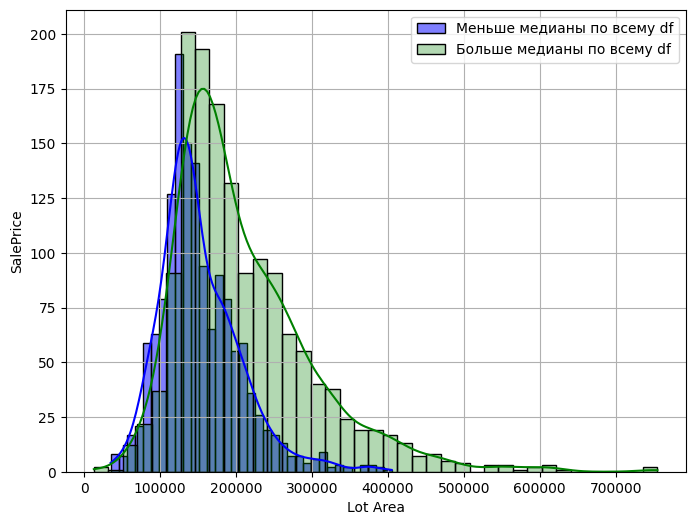

In [9]:
plot_hists(
    group1_by_lot_area,
    group2_by_lot_area,
    "Меньше медианы по всему df",
    "Больше медианы по всему df",
    "Lot Area"
)

Анализируем гистограммы в двух группах по Lot Area: 

- Распределение в группе меньше медианы (которая считалась по всему initial_df) похоже на нормальное, но присутствует некоторая ассиметрия.
- Распределение в группе больше медианы также в целом напоминает нормальное, но присутствует выброс, а также сильная ассиметрия.

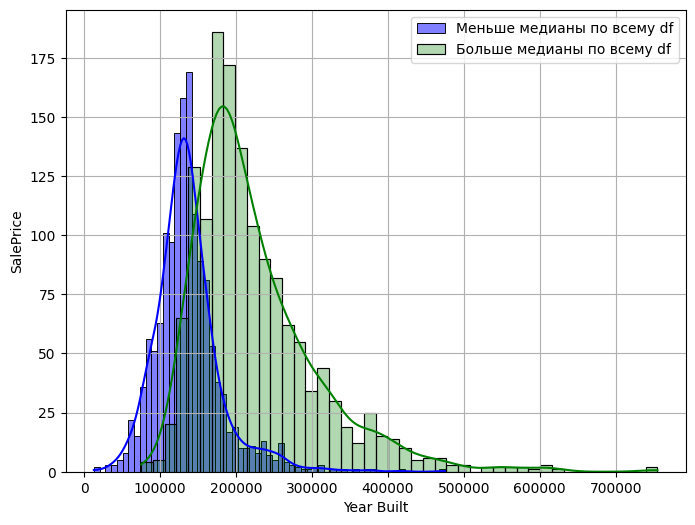

In [10]:
plot_hists(
    group1_by_year_built,
    group2_by_year_built,
    "Меньше медианы по всему df",
    "Больше медианы по всему df",
    "Year Built"
)

Анализируем гистограммы в двух группах по Year Built: 

- Распределение в группе меньше медианы (которая считалась по всему initial_df) похоже на нормальное, но присутствует некоторая ассиметрия, а также очень длинный хвост вправо - что также свидительствует о наличии выбросов (их в целом можно заметить).
- Распределение в группе больше медианы также в целом напоминает нормальное, но присутствует выброс, а также сильная ассиметрия.

**Вывод:** В связи с тем, что и при использовании теста Шапиро-Уилка и при использовании теста Лиллиефорса мы были вынуждены отклонить нулевую гипотезу о нормальности распределения SalePrice для всех групп, а также при наличие выбросов на всех гистограммах и ассиметрии мы не будем использовать t-test, вместо этого используем критерий Манна-Уитни для медиан.

**Проверим гипотезу для равенства медиан в группах group1_by_lot_area (Lot Area меньше медианы Lot Area по всему initial_df), и group1_by_lot_area (Lot Area больше медианы Lot Area по всему initial_df).**

$H_0: \text{median}(\text{group1\_by\_lot\_area}[\text{"SalePrice"}]) = \text{median}(\text{group2\_by\_lot\_area}[\text{"SalePrice"}])$
$H_1: \text{median}(\text{group1\_by\_lot\_area}[\text{"SalePrice"}]) != \text{median}(\text{group2\_by\_lot\_area}[\text{"SalePrice"}])$

In [11]:
def print_hypothesis_conclusion(p_value: float) -> None:
    if p_value < 0.05:
        print(f"Нулевая гипотеза (медианы равны) отвергнута")
    else:
        print(f"Нулевая гипотеза (медианы равны) не отвергнута")

# Применяем критерий Манна-Уитни для медиан
lot_area_mw = stats.mannwhitneyu(
    group1_by_lot_area["SalePrice"],
    group2_by_lot_area["SalePrice"],
    alternative="two-sided",
)

print(f"p_value: {lot_area_mw[1]}", end="\n\n")
print_hypothesis_conclusion(lot_area_mw[1])

p_value: 4.241365162090767e-88

Нулевая гипотеза (медианы равны) отвергнута


Мы отвергаем нулевую гипотезу о равенстве медиан. Медиана цены домов, в группе с lot_area (площадью) больше, чем медиана lot_area по всему датасету, больше, чем в другой группе.

Посмотрим на boxplot.

In [12]:
group1_by_lot_area["SalePrice"].median(), group2_by_lot_area["SalePrice"].median()

(np.float64(141500.0), np.float64(185000.0))

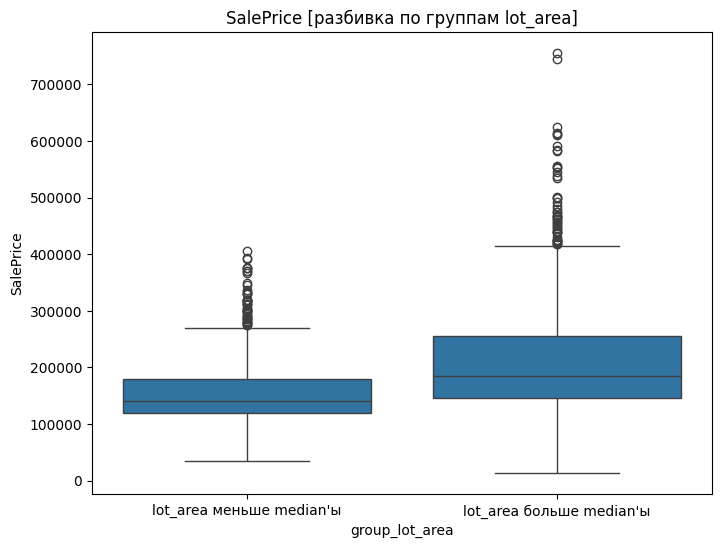

In [13]:
def plot_boxplot(
    group_1_df,
    group_2_df,
    xlabel, 
):
    group_1_df[f'group_{xlabel}'] = f"{xlabel} меньше median'ы"
    group_2_df[f'group_{xlabel}'] = f"{xlabel} больше median'ы"
    combined = pd.concat([group_1_df, group_2_df])

    # Строим график
    plt.figure(figsize=(8,6))

    sns.boxplot(x=f'group_{xlabel}', y="SalePrice", data=combined)

    plt.title(f"SalePrice [разбивка по группам {xlabel}]")
    plt.xlabel(f'group_{xlabel}')
    plt.ylabel("SalePrice")
    plt.show()

plot_boxplot(
    group1_by_lot_area,
    group2_by_lot_area,
    "lot_area",
)

**Выводы по Boxplot:**

- Медиана SalePrice в группе "lot area больше медианы" заметно выше чем в группе "lot_area меньше медианы". Визуально подтверждает, что объекты с большой площадью стоят дороже.
  
- IQR в группе "lot area больше медианы" сильно шире. Это в целом логично, так как большие участки могут часто стоить дорого, а иногда стоять заброшенными полями.

- Выбросов заметно больше в группе "lot_area больше медианы". Есть очень дорогие элитные дома.

- В целом box'ы пересекаются не очень сильно.

Теперь проверим вторую гипотезу.

**Проверим гипотезу для равенства медиан в группах group1_by_year_built (year_built (Год постройки) меньше медианы year_built по всему initial_df), и group1_by_year_built (year_built (Год постройки) больше медианы year_built по всему initial_df).**

$H_0: \text{median}(\text{group1\_by\_year\_built}[\text{"SalePrice"}]) = \text{median}(\text{group2\_by\_year\_built}[\text{"SalePrice"}])$
$H_1: \text{median}(\text{group1\_by\_year\_built}[\text{"SalePrice"}]) != \text{median}(\text{group2\_by\_year\_built}[\text{"SalePrice"}])$

In [14]:
# Применяем критерий Манна-Уитни для медиан
year_built_mw = stats.mannwhitneyu(
    group1_by_year_built["SalePrice"],
    group2_by_year_built["SalePrice"],
    alternative="two-sided",
)

print(f"p_value: {year_built_mw[1]}", end="\n\n")
print_hypothesis_conclusion(year_built_mw[1])

p_value: 3.170486907733785e-271

Нулевая гипотеза (медианы равны) отвергнута


Мы отвергаем нулевую гипотезу о равенстве медиан. Медиана цены домов, в группе с year_built (годом постройки) больше, чем медиана year_built по всему датасету, больше, чем в другой группе. Иначе говоря, более новые дома стоят больше.

Посмотрим на boxplot.

In [15]:
group1_by_year_built["SalePrice"].median(), group2_by_year_built["SalePrice"].median()

(np.float64(132000.0), np.float64(204000.0))

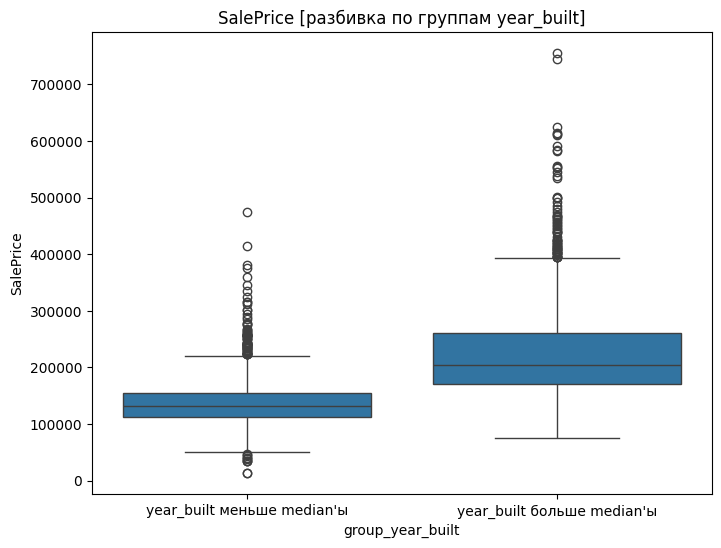

In [16]:
plot_boxplot(
    group1_by_year_built,
    group2_by_year_built,
    "year_built",
)

- Медиана SalePrice в группе "year_built больше медианы" заметно выше чем в группе "year_built меньше медианы". Визуально подтверждает, что более новые дома стоят дороже. Разница между медианами сильнее, чем в случае разбивки по lot_area.

- IQR у новых домов значительно шире. Так как новые дома это и дешевые новостройки и элитные дома.

- IQR у старых домов заметно более узкий: старые дома в основном стоят немного и однородно по цене.

- box'ы перекрываются довольно слабо, год постройки лучше наблюдения/дома по цене, чем lot_area.

- Выбросов много в обеих группах, но более экстремальные в группе с year_built больше медианыю

**Финальный вывод:** 

- Нам не удалось опровергнуть гипотезу о том, что медианы SalePrice в двух группах (одна с меньшими lot_area (площадь объекта), другая с большими: равны).

- Нам не удалось опровергнуть гипотезу о том, что медианы SalePrice в двух группах (одна с меньшими year_built (год постройк), другая с большими: равны).

Цена дома не не зависит от lot_area и year_built.